#  Comparative Analysis & Final Dashboard Architecture
**Project:** Historical Weather India (2000-2024)
**Core Story:** How have temperature, rainfall, seasonality, and weather extremes varied across 10 major Indian cities from 2000 to 2024?


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load primary cleaned dataset
df = pd.read_csv("../data/processed/weather_analysis_ready.csv", parse_dates=["date"])

print(f"Data shape loaded for comparative analysis: {df.shape}")
print(f"Columns checked: {df.columns.tolist()}")

Data shape loaded for comparative analysis: (91320, 21)
Columns checked: ['city', 'date', 'temperature_2m_max', 'temperature_2m_min', 'apparent_temperature_max', 'apparent_temperature_min', 'precipitation_sum', 'rain_sum', 'weather_code', 'wind_speed_10m_max', 'wind_gusts_10m_max', 'wind_direction_10m_dominant', 'year', 'month', 'month_name', 'day', 'month_order', 'season', 'temperature_range', 'avg_temperature', 'rainy_day']


In [2]:
# Aggregate record limits and count metrics per city
city_coverage = df.groupby("city").agg(
    records=("date", "count"),
    start_date=("date", "min"),
    end_date=("date", "max")
).reset_index()

print("=== CITY TEMPORAL COVERAGE AUDIT ===")
print(city_coverage)

print("\n=== UNIQUE YEARS TRACKED PER CITY ===")
print(df.groupby("city")["year"].nunique())

=== CITY TEMPORAL COVERAGE AUDIT ===
        city  records start_date   end_date
0  Ahmedabad     9132 2000-01-01 2024-12-31
1  Bangalore     9132 2000-01-01 2024-12-31
2    Chennai     9132 2000-01-01 2024-12-31
3      Delhi     9132 2000-01-01 2024-12-31
4  Hyderabad     9132 2000-01-01 2024-12-31
5     Jaipur     9132 2000-01-01 2024-12-31
6    Kolkata     9132 2000-01-01 2024-12-31
7    Lucknow     9132 2000-01-01 2024-12-31
8     Mumbai     9132 2000-01-01 2024-12-31
9       Pune     9132 2000-01-01 2024-12-31

=== UNIQUE YEARS TRACKED PER CITY ===
city
Ahmedabad    25
Bangalore    25
Chennai      25
Delhi        25
Hyderabad    25
Jaipur       25
Kolkata      25
Lucknow      25
Mumbai       25
Pune         25
Name: year, dtype: int64


=== LONG-TERM CITY TEMPERATURE RANKINGS ===
        city  avg_temperature  avg_max_temperature  avg_min_temperature
2    Chennai        28.410113            31.896890            24.923336
0  Ahmedabad        27.475405            33.150142            21.800668
8     Mumbai        27.051834            30.513184            23.590484
6    Kolkata        26.437719            30.684932            22.190506
4  Hyderabad        26.310671            31.230103            21.391240
9       Pune        25.435699            30.691962            20.179435
7    Lucknow        25.362900            30.768780            19.957019
5     Jaipur        25.255355            31.114893            19.395817
3      Delhi        24.947832            30.641349            19.254314
1  Bangalore        23.464241            28.316798            18.611684


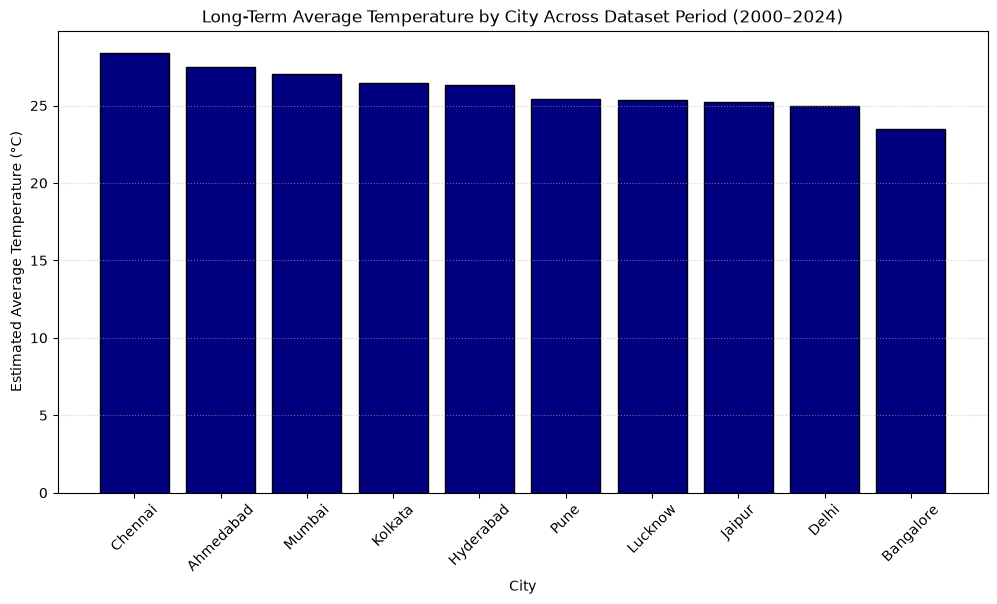

In [3]:
# Compute long-term aggregated averages per city container
city_temperature = df.groupby("city", as_index=False).agg(
    avg_temperature=("avg_temperature", "mean"),
    avg_max_temperature=("temperature_2m_max", "mean"),
    avg_min_temperature=("temperature_2m_min", "mean")
).sort_values("avg_temperature", ascending=False)

print("=== LONG-TERM CITY TEMPERATURE RANKINGS ===")
print(city_temperature)

# Bar chart visualization
plt.figure(figsize=(12, 6))
plt.bar(city_temperature["city"], city_temperature["avg_temperature"], color="navy", edgecolor="black")
plt.xlabel("City")
plt.ylabel("Estimated Average Temperature (°C)")
plt.title("Long-Term Average Temperature by City Across Dataset Period (2000–2024)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.show()

In [4]:
# Extract city-level distribution variables
city_rainfall = df.groupby("city", as_index=False).agg(
    avg_daily_rainfall=("rain_sum", "mean"),
    median_daily_rainfall=("rain_sum", "median"),
    rainy_days=("rainy_day", "sum"),
    maximum_daily_rainfall=("rain_sum", "max")
)

# Derive baseline city metrics using actual recorded city observations length
city_sizes = df.groupby("city").size().values
city_rainfall["rainy_day_percentage"] = (city_rainfall["rainy_days"] / city_sizes) * 100

# Sort according to daily volumes
city_rainfall = city_rainfall.sort_values("avg_daily_rainfall", ascending=False)

print("=== SORTED CITY-LEVEL MOISTURE PROFILES ===")
print(city_rainfall)

=== SORTED CITY-LEVEL MOISTURE PROFILES ===
        city  avg_daily_rainfall  median_daily_rainfall  rainy_days  \
8     Mumbai            5.694284                    0.0        3664   
6    Kolkata            4.551456                    0.2        4837   
9       Pune            4.274956                    0.0        4103   
2    Chennai            3.007643                    0.1        4843   
7    Lucknow            2.774693                    0.0        3381   
1  Bangalore            2.620456                    0.2        4895   
0  Ahmedabad            2.449255                    0.0        2542   
4  Hyderabad            2.229895                    0.0        3889   
3      Delhi            1.851774                    0.0        3144   
5     Jaipur            1.473095                    0.0        2705   

   maximum_daily_rainfall  rainy_day_percentage  
8                   251.1             40.122646  
6                   155.4             52.967587  
9                   156.

In [5]:
# Build multi-index context frame mapping micro-seasonal responses
city_season = df.groupby(["city", "season"], as_index=False).agg(
    avg_temperature=("avg_temperature", "mean"),
    avg_daily_rainfall=("rain_sum", "mean"),
    rainy_days=("rainy_day", "sum"),
    avg_wind_speed=("wind_speed_10m_max", "mean")
)

print("=== CITY-SEASON CROSS-EXAMINATION MATRIX PREVIEW ===")
print(city_season.head(20))

=== CITY-SEASON CROSS-EXAMINATION MATRIX PREVIEW ===
         city        season  avg_temperature  avg_daily_rainfall  rainy_days  \
0   Ahmedabad       Monsoon        29.332459            7.034459        2242   
1   Ahmedabad  Post-Monsoon        26.858197            0.391279         143   
2   Ahmedabad        Summer        30.876522            0.101217         108   
3   Ahmedabad        Winter        21.916992            0.036331          49   
4   Bangalore       Monsoon        23.298984            4.262852        2683   
5   Bangalore  Post-Monsoon        22.155836            3.681049         940   
6   Bangalore        Summer        26.261978            1.908478         940   
7   Bangalore        Winter        21.720580            0.409925         332   
8     Chennai       Monsoon        30.301918            3.072393        2259   
9     Chennai  Post-Monsoon        26.931574            7.951279        1167   
10    Chennai        Summer        30.089043            0.892739   

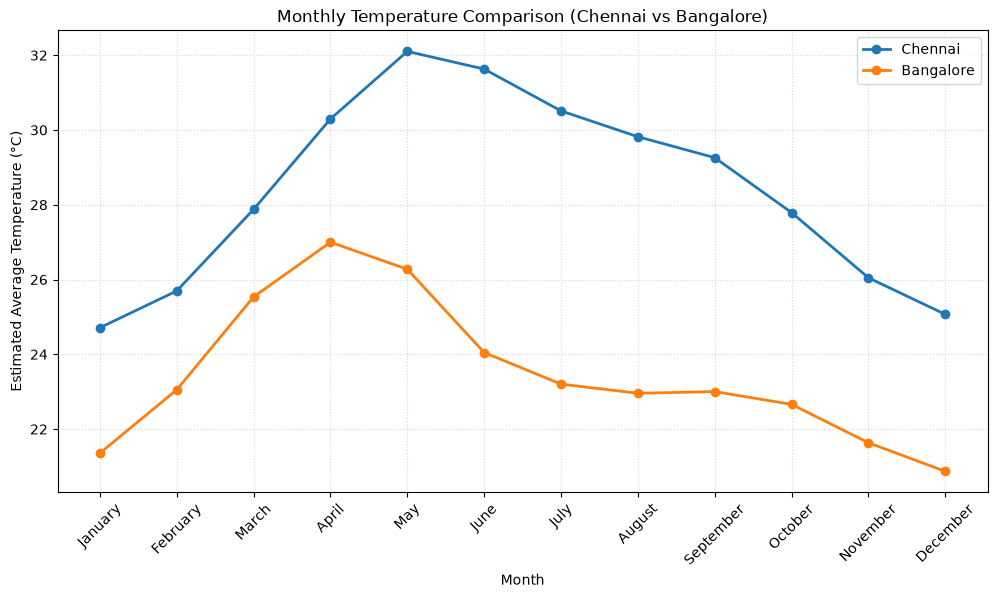

In [6]:
# Track monthly timelines grouped per city
city_monthly = df.groupby(["city", "month", "month_name"], as_index=False).agg(
    avg_temperature=("avg_temperature", "mean"),
    avg_daily_rainfall=("rain_sum", "mean")
).sort_values(["city", "month"])

# Define structural subset comparison criteria
selected_cities = ["Chennai", "Bangalore"]
comparison = city_monthly[city_monthly["city"].isin(selected_cities)]

# Render Comparative Timeline Plot
plt.figure(figsize=(12, 6))
for city in selected_cities:
    city_data = comparison[comparison["city"] == city]
    plt.plot(city_data["month_name"], city_data["avg_temperature"], marker="o", linewidth=2, label=city)

plt.xlabel("Month")
plt.ylabel("Estimated Average Temperature (°C)")
plt.title("Monthly Temperature Comparison (Chennai vs Bangalore)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()

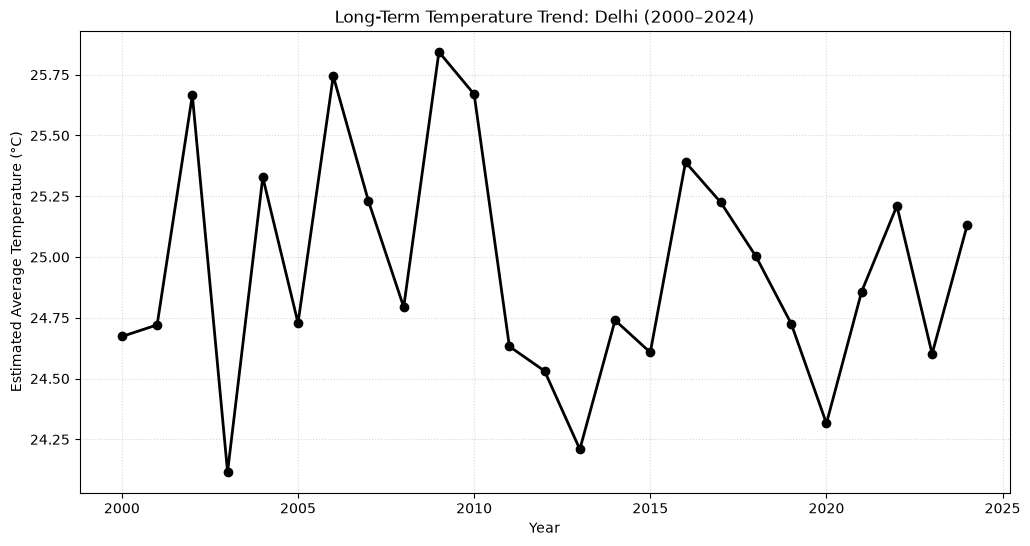

In [7]:
# Compound data frames across long-term city parameters
city_year_trend = df.groupby(["city", "year"], as_index=False).agg(
    avg_temperature=("avg_temperature", "mean"),
    avg_daily_rainfall=("rain_sum", "mean"),
    maximum_temperature=("temperature_2m_max", "max"),
    minimum_temperature=("temperature_2m_min", "min")
)

# Isolate representative tracking node (Delhi) for design verification
city_name = "Delhi"
city_data = city_year_trend[city_year_trend["city"] == city_name]

# Render Timeline Plot
plt.figure(figsize=(12, 6))
plt.plot(city_data["year"], city_data["avg_temperature"], marker="o", color="black", linewidth=2)
plt.xlabel("Year")
plt.ylabel("Estimated Average Temperature (°C)")
plt.title(f"Long-Term Temperature Trend: {city_name} (2000–2024)")
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()

In [8]:
# Isolate top 10 maximums
hottest_records = df.nlargest(10, "temperature_2m_max")[["city", "date", "temperature_2m_max"]]

# Isolate top 10 minimums
coldest_records = df.nsmallest(10, "temperature_2m_min")[["city", "date", "temperature_2m_min"]]

# Isolate top 10 rain events
highest_rainfall = df.nlargest(10, "rain_sum")[["city", "date", "rain_sum"]]

# Isolate top 10 wind parameters
highest_wind = df.nlargest(10, "wind_speed_10m_max")[["city", "date", "wind_speed_10m_max"]]

print("=== RECORD EXTRACTION COMPLETE: HIGHEST RECORDED VALUES IN THIS DATASET ===")

=== RECORD EXTRACTION COMPLETE: HIGHEST RECORDED VALUES IN THIS DATASET ===


In [9]:
# Compute global proportions
weather_code_distribution = df["weather_code"].value_counts(normalize=True).mul(100).sort_values(ascending=False)
print("=== GLOBAL WEATHER CODE PERCENTAGE DISTRIBUTION ===")
print(weather_code_distribution)

# Cross tabulate ratios by city dimensions
city_crosstab = pd.crosstab(df["city"], df["weather_code"], normalize="index") * 100
print("\n=== CITY × WEATHER CODE DISTRIBUTION SHARE (%) ===")
print(city_crosstab.head(10))

# Cross tabulate ratios by historical year dimensions
year_crosstab = pd.crosstab(df["year"], df["weather_code"], normalize="index") * 100
print("\n=== YEAR × WEATHER CODE DISTRIBUTION SHARE (%) ===")
print(year_crosstab.head(10))

=== GLOBAL WEATHER CODE PERCENTAGE DISTRIBUTION ===
weather_code
3     23.573149
0     17.021463
51    13.581910
63     9.289312
1      8.995839
2      8.794350
61     7.474814
53     7.278800
55     2.687254
65     1.303110
Name: proportion, dtype: float64

=== CITY × WEATHER CODE DISTRIBUTION SHARE (%) ===
weather_code         0          1          2          3          51  \
city                                                                  
Ahmedabad     33.037670  11.585633   8.661848  18.878668  12.768287   
Bangalore      3.712221   3.537013   6.416995  32.731056  18.845817   
Chennai        0.788436   4.380201   9.077968  32.720105  20.510293   
Delhi         24.277267  10.742444   8.004818  22.547087  11.476128   
Hyderabad     10.074463   8.388086  10.030661  28.920280  15.867280   
Jaipur        25.591327  13.567674   9.833552  21.386334  10.928603   
Kolkata       13.261060   7.271134   7.216382  19.283837  11.322821   
Lucknow       25.043802  11.344722   7.424442  19.1

In [10]:
# Define structural aggregation output container directory path parameters
output_dir = "../data/processed/dashboard/"
os.makedirs(output_dir, exist_ok=True)

# Export structural dashboard files
city_temperature.to_csv(os.path.join(output_dir, "city_temperature.csv"), index=False)
city_rainfall.to_csv(os.path.join(output_dir, "city_rainfall.csv"), index=False)
city_season.to_csv(os.path.join(output_dir, "city_season.csv"), index=False)
city_monthly.to_csv(os.path.join(output_dir, "city_monthly.csv"), index=False)
city_year_trend.to_csv(os.path.join(output_dir, "city_year_trend.csv"), index=False)
hottest_records.to_csv(os.path.join(output_dir, "hottest_records.csv"), index=False)
coldest_records.to_csv(os.path.join(output_dir, "coldest_records.csv"), index=False)
highest_rainfall.to_csv(os.path.join(output_dir, "highest_rainfall.csv"), index=False)
highest_wind.to_csv(os.path.join(output_dir, "highest_wind.csv"), index=False)

print(f"Success! All 9 pre-aggregated files exported cleanly to: {output_dir}")

Success! All 9 pre-aggregated files exported cleanly to: ../data/processed/dashboard/
